# center and edge trace smoke test (HDF5)


In [6]:
import matplotlib.pyplot as plt

def plot_traces(traces, fs=3_906_250, offset_step=70, title="QP Traces"):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    plt.figure(figsize=(18, 12))

    for i in range(num_channels):
        color = 'orange' if i > 19 else 'tab:blue'
        y = traces[i] + i * offset_step
        plt.plot(time_ms, y, lw=0.4, color=color)

        plt.text(
            time_ms[0] - 0.05 * time_ms[-1],  # small shift to the left
            y[0],
            f"{i}",
            va="center",
            ha="right",
            fontsize=9,
            color=color,
            fontweight="bold"
        )

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])

    plt.tight_layout()
    plt.show()


Using: /ceph/dwong/trigger_samples/sanity_check_Jan12/edge/NR_traces_energy_500_pair_batch_0000.h5


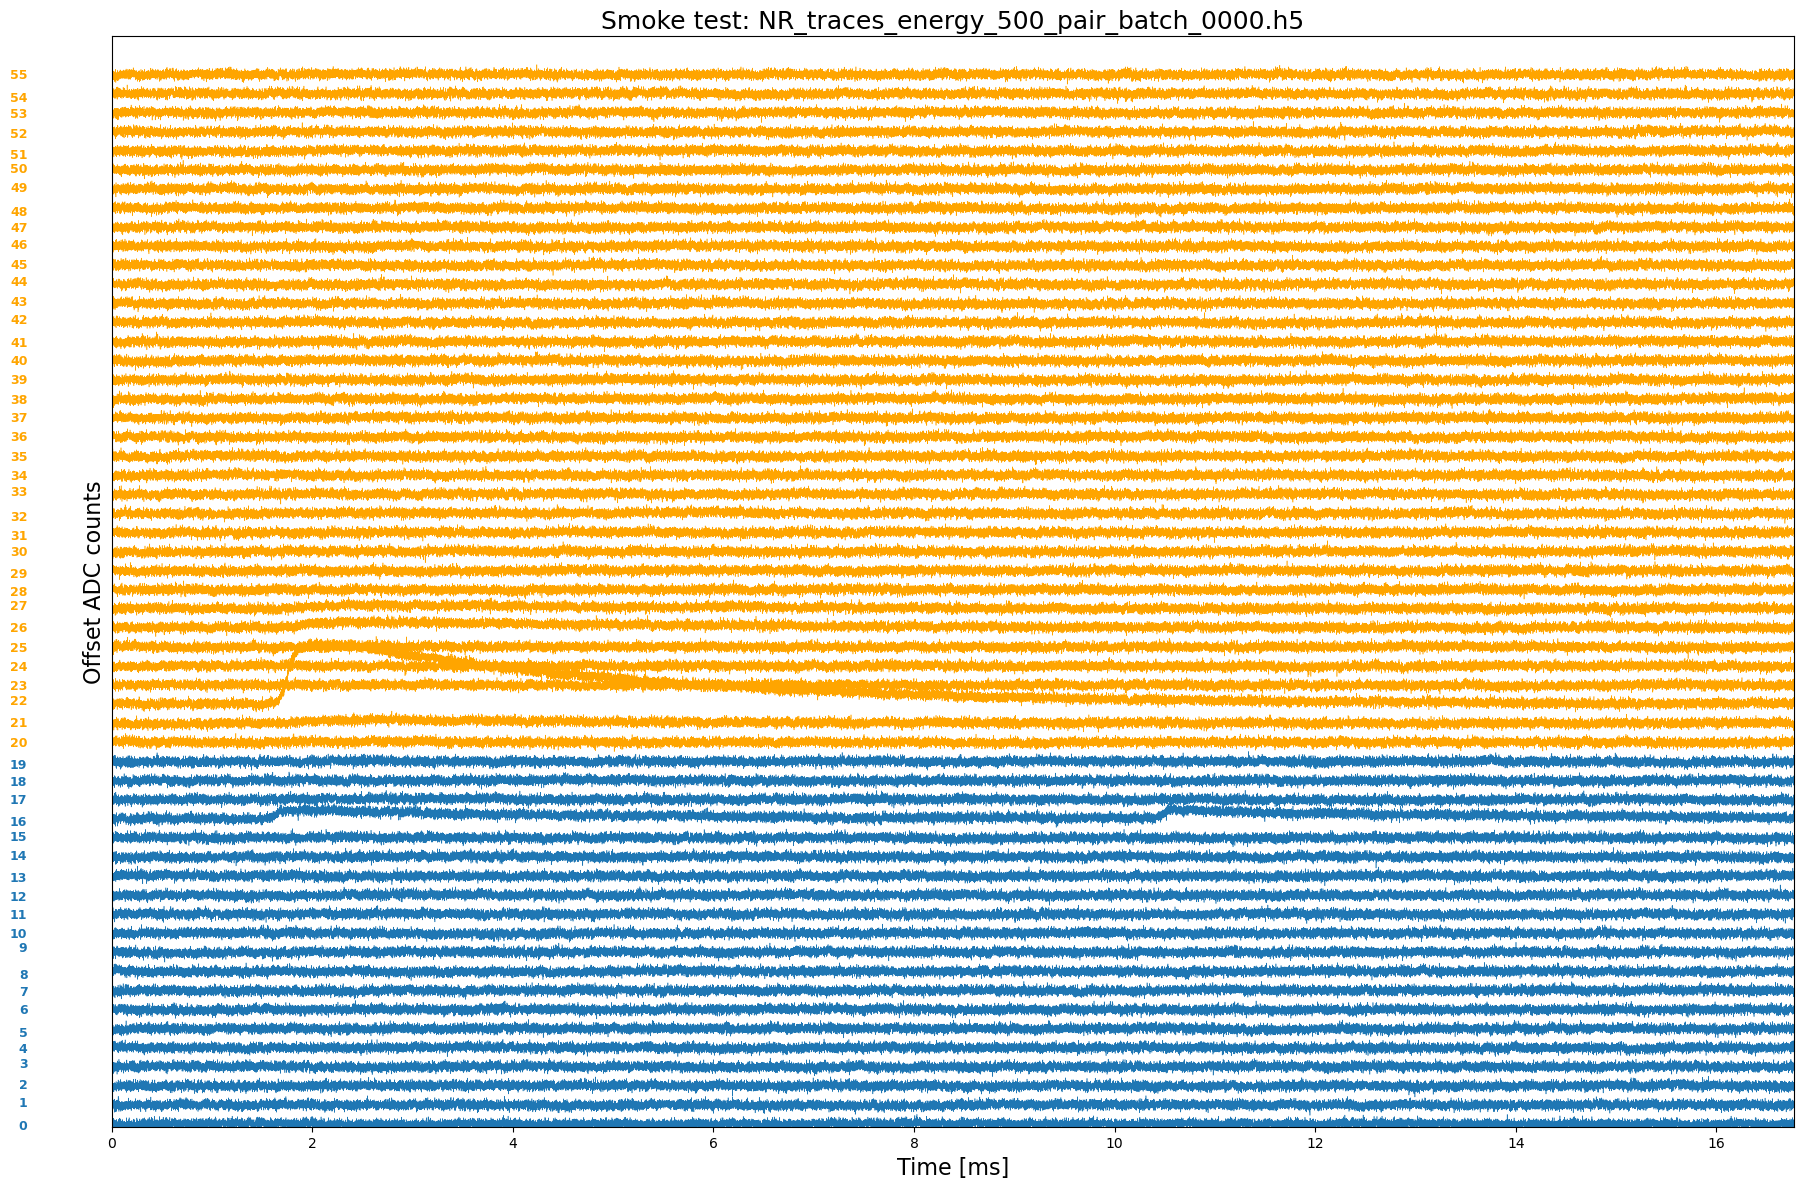

In [7]:
from pathlib import Path
import h5py

from trace_IO import plot_traces

# Point to a .h5 trace file (edit as needed)
TRACE_PATH = Path('/ceph/dwong/trigger_samples/sanity_check_Jan12/edge')
TRACE_FILE = None  # set to a specific file if you want

if TRACE_FILE is None:
    matches = sorted(TRACE_PATH.glob('*.h5'))
    if not matches:
        raise FileNotFoundError(f'No .h5 files found in {TRACE_PATH}')
    TRACE_FILE = matches[30]

print('Using:', TRACE_FILE)
with h5py.File(TRACE_FILE, 'r') as f:
    # Expect dataset shape: (n_events, n_channels, n_samples)
    traces = f['traces'][10]

plot_traces(traces, title=f'Smoke test: {TRACE_FILE.name}')

Using: /ceph/dwong/trigger_samples/sanity_check_Jan12/center/ER_traces_energy_5000_pair_batch_0000.h5


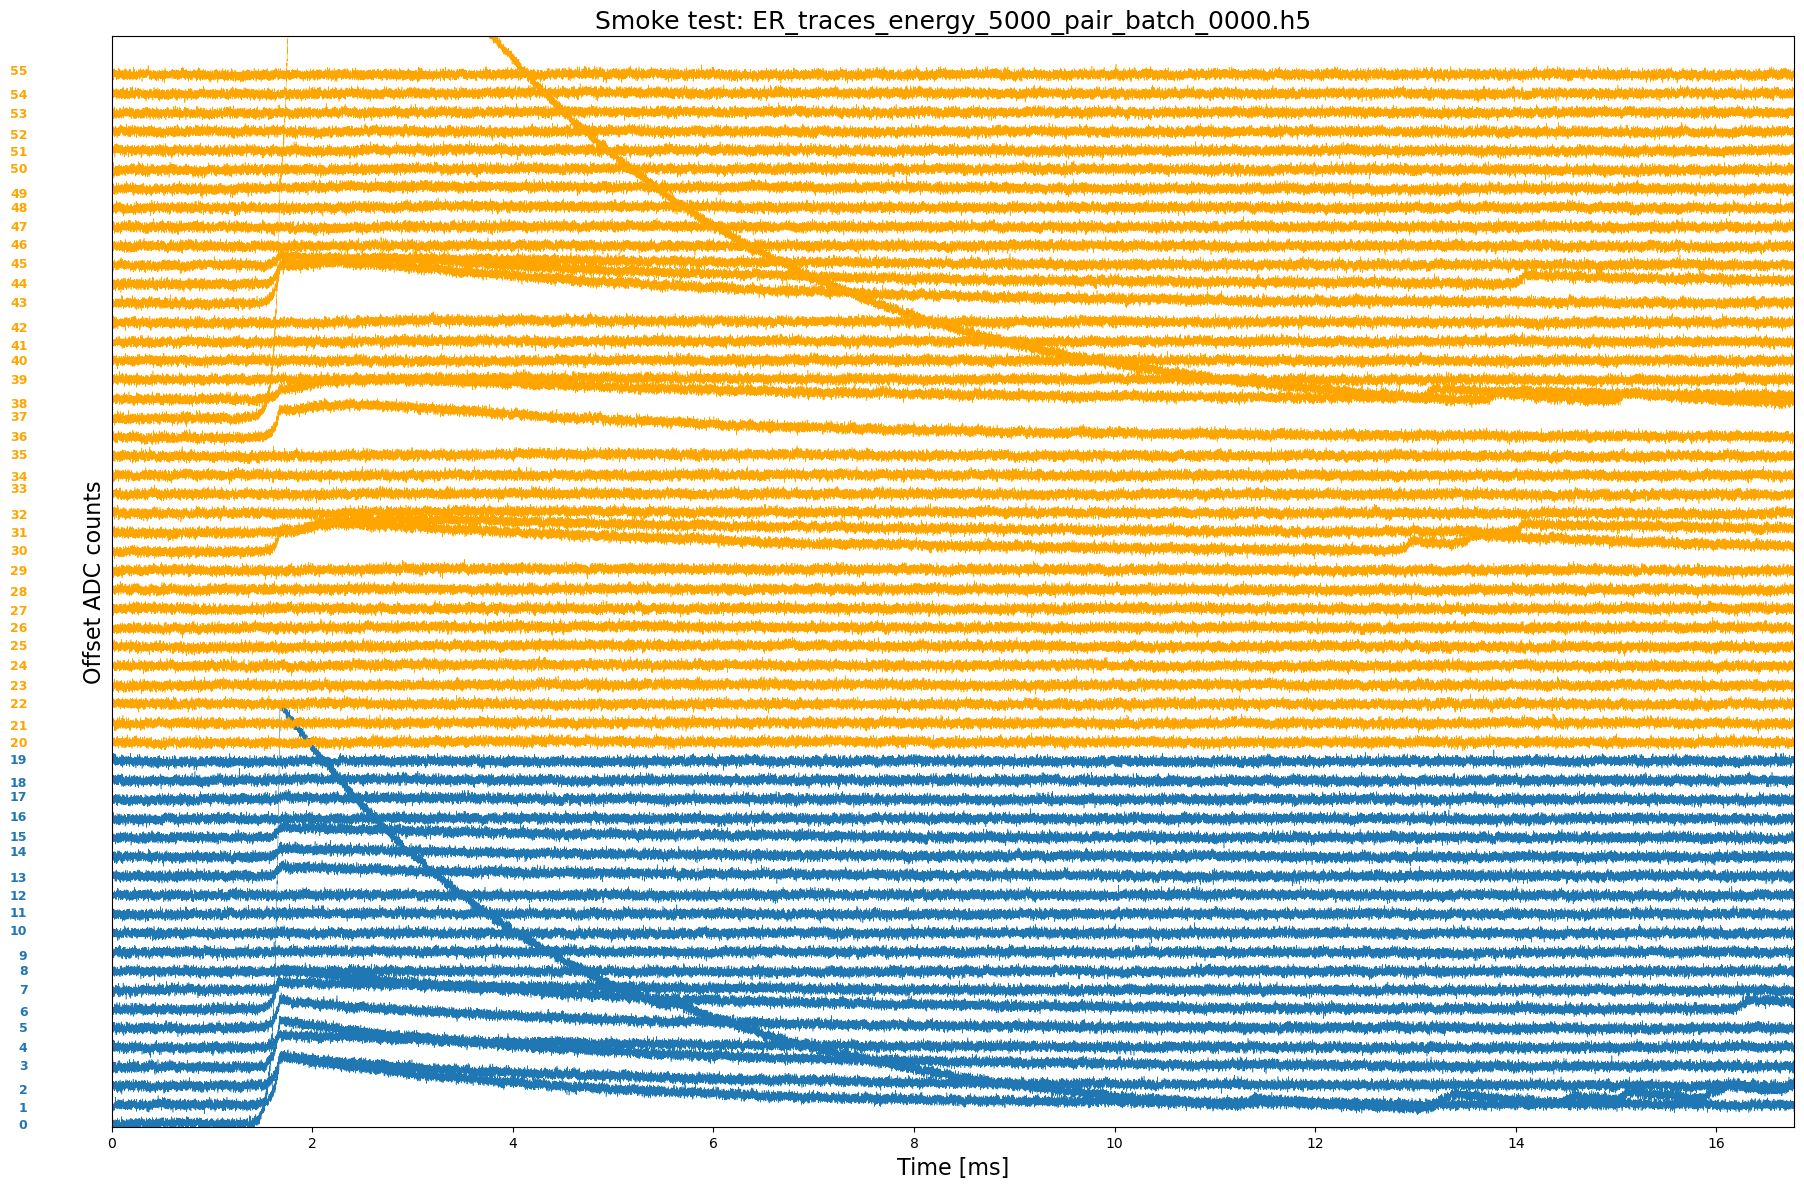

In [8]:
from pathlib import Path
import h5py

from trace_IO import plot_traces

# Point to a .h5 trace file (edit as needed)
TRACE_PATH = Path('/ceph/dwong/trigger_samples/sanity_check_Jan12/center')
TRACE_FILE = None  # set to a specific file if you want

if TRACE_FILE is None:
    matches = sorted(TRACE_PATH.glob('*.h5'))
    if not matches:
        raise FileNotFoundError(f'No .h5 files found in {TRACE_PATH}')
    TRACE_FILE = matches[0]

print('Using:', TRACE_FILE)
with h5py.File(TRACE_FILE, 'r') as f:
    # Expect dataset shape: (n_events, n_channels, n_samples)
    traces = f['traces'][0]

plot_traces(traces, title=f'Smoke test: {TRACE_FILE.name}')

In [11]:
from pathlib import Path
import h5py

BASE = Path('/ceph/dwong/trigger_samples/sanity_check_Jan12')
DIRS = ['center', 'edge']

def check_h5_dir(d):
    path = BASE / d
    files = sorted(path.glob('*.h5'))
    if not files:
        print(f'{d}: no .h5 files found in {path}')
        return
    bad = []
    for fp in files:
        if not h5py.is_hdf5(fp):
            bad.append((fp.name, 'not_hdf5'))
            continue
        try:
            with h5py.File(fp, 'r') as f:
                _ = f.keys()
        except Exception as exc:
            bad.append((fp.name, str(exc)))
    if bad:
        print(f'{d}: {len(bad)} bad file(s)')
        for name, err in bad:
            print(f'  {name}: {err}')
    else:
        print(f'{d}: all {len(files)} file(s) OK')

for d in DIRS:
    check_h5_dir(d)


center: all 40 file(s) OK
edge: all 40 file(s) OK
